In [1]:
import os
import io
import copy
import time

from multiprocessing import Pool
from pathlib import Path
from typing import List, Tuple
import urllib.request
from glob import glob

from joblib import Parallel, delayed

# from torch.utils.tensorboard.summary import audio
# from tqdm import tqdm
from tqdm.notebook import tqdm
from itertools import cycle

from scipy.io import wavfile
import soundfile as sf
import librosa
import librosa.display
import IPython
import IPython.display as ipd
import noisereduce as nr
from noisereduce.generate_noise import band_limited_noise

import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pylab as plt
import seaborn as sns

# print('Vamos con toda!')

## Load the Data

In [2]:
sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [3]:
cwd = os.getcwd()  # cwd: /home/fs72552/vargas/forests-sounds-vargas/source
cwd = str(Path(cwd).parents[0])
print(cwd)
path_data = f"{cwd}/data/"
path_out = f"{cwd}/out/"

configfiles = [(dirpath.split('/')[-1], os.path.join(dirpath, f))
               for dirpath, dirnames, files in os.walk(path_data)
               for f in files if f.endswith('.mp3')]

C:\Users\cav\repos\forests-sounds-vargas


In [4]:
sreg, si = 0, 0
uniqueRegions = list(set(r[0] for r in configfiles))
region = uniqueRegions[sreg]
audio_files = [f[1] for f in configfiles if f[0] == region]
print(audio_files[:3])
print(f'{region} =>', len(audio_files))

['C:\\Users\\cav\\repos\\forests-sounds-vargas/data/RefForest\\RefForest1.mp3', 'C:\\Users\\cav\\repos\\forests-sounds-vargas/data/RefForest\\RefForest4.mp3', 'C:\\Users\\cav\\repos\\forests-sounds-vargas/data/RefForest\\RefForest5.mp3']
RefForest => 3


In [5]:
# ipd.Audio(audio_files[si])

In [6]:
# TODO: CREATE PARALLEL JOB PER FILE
y, sr = librosa.load(audio_files[si], sr=None)  #, duration=1800)
time = int(len(y) / sr)
print(f'y: {y[:9]}')
print(f'total samples in y: {y.shape} in time: {time} secs')
print(f'samples rate per second:  {sr}')

y: [ 0.01103865  0.01176985  0.00412414 -0.00774774 -0.01663554 -0.01605902
 -0.00705433  0.00213126  0.0058885 ]
total samples in y: (86400000,) in time: 1800 secs
samples rate per second:  48000


## Data Exploratory Analysis (DEA)

In [7]:
y_c = copy.deepcopy(y)
print('###', 'ORIGINAL Y_C', len(y_c), y_c[:9], type(y_c))
my_chunks = 1800 / 3  # [1800 / 3 => per 3 seconds, 1800 / 30 => per 30 seconds, 1800 / 60 => per 60 seconds, 1800 => per second]
split_y = np.hsplit(y_c, my_chunks)
print('###', 'CHUNKS Y_C',
      f'total_chunks: {len(split_y)}',
      f'chunk_size: {len(split_y[0])}',
      type(split_y), type(split_y[0])
      )

### ORIGINAL Y_C 86400000 [ 0.01103865  0.01176985  0.00412414 -0.00774774 -0.01663554 -0.01605902
 -0.00705433  0.00213126  0.0058885 ] <class 'numpy.ndarray'>
### CHUNKS Y_C total_chunks: 600 chunk_size: 144000 <class 'list'> <class 'numpy.ndarray'>


In [8]:
# print(type(split_y), len(split_y), len(split_y[0]), split_y[0][:9], type(split_y[0]))

In [9]:
# wrap audio_denoise with parameters
def audio_denoise_st(y=None, sr: int = 48000):
    return nr.reduce_noise(y=y, sr=sr, n_std_thresh_stationary=1.9, stationary=True)


def audio_denoise_ns(y=None, sr: int = 48000):
    return nr.reduce_noise(y=y, sr=sr, n_std_thresh_stationary=1.6, stationary=False)

In [10]:
# single core audio_denoise => ~3min
# y_rn_st = audio_denoise_st(y_c)
# y_rn_ns = audio_denoise_ns(y_c)

In [11]:
# parallel audio_denoise => ~30secs
split_y_rn_st = Parallel(n_jobs=-1, verbose=1)(delayed(audio_denoise_st)(y_i) for y_i in split_y)
split_y_rn_ns = Parallel(n_jobs=-1, verbose=1)(delayed(audio_denoise_ns)(y_i) for y_i in split_y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   12.5s


KeyboardInterrupt: 

In [12]:
print('###', 'SPLIT DENOISE Y_C', type(split_y_rn_st), len(split_y_rn_st), len(split_y_rn_st[0]))

### SPLIT DENOISE Y_C <class 'list'> 600 144000


In [13]:
# REARRANGE THE SIGNAL
y_rn_st_p = []
y_rn_ns_p = []
for s_st in split_y_rn_st:
    y_rn_st_p.extend(s_st)
for s_ns in split_y_rn_ns:
    y_rn_ns_p.extend(s_ns)

In [14]:
print('###', 'SPLIT DENOISE Y_C REARRANGED', type(y_rn_st_p), len(y_rn_st_p), y_rn_st_p[:9])

### SPLIT DENOISE Y_C REARRANGED <class 'list'> 86400000 [0.00037547704, -0.00014516509, 5.1267314e-05, 0.00010961771, -0.0001111397, -3.6639438e-05, 1.0882228e-05, -5.9926828e-05, 3.7033813e-05]


In [15]:
def split_freq_band(s: np.memmap = None, sr: int = 48000, b_band: int = 0, u_band: int = 10000,
                    bandwidth: int = 1000) -> List[np.ndarray]:
    # Calculate the FFT
    y_fft = np.fft.fft(s)
    # Calculate the frequencies for the FFT
    fft_freq = np.fft.fftfreq(len(s), 1.0 / sr)
    signals = []
    for f in range(b_band, u_band, bandwidth):
        mask = (fft_freq >= f) & (fft_freq < f + bandwidth)
        y_fft_band = y_fft[mask]
        fft_freq_band = fft_freq[mask]
        y_band = np.fft.ifft(y_fft_band)
        y_band = np.real(y_band)  # Take only the real part
        signals.append(y_band)
    return signals

In [16]:
# single core split_freq_band => ~30sec
# y_rn_st_split = split_freq_band(y_rn_st)
# y_rn_ns_split = split_freq_band(y_rn_ns)

In [17]:
# print(
#     '###', 'SPLIT DENOISE Y_C SPLIT PER FREQUENCY',
#     len(y_rn_st_split), type(y_rn_st_split[0]), len(y_rn_st_split[0]), y_rn_st_split[0][:9]
# )

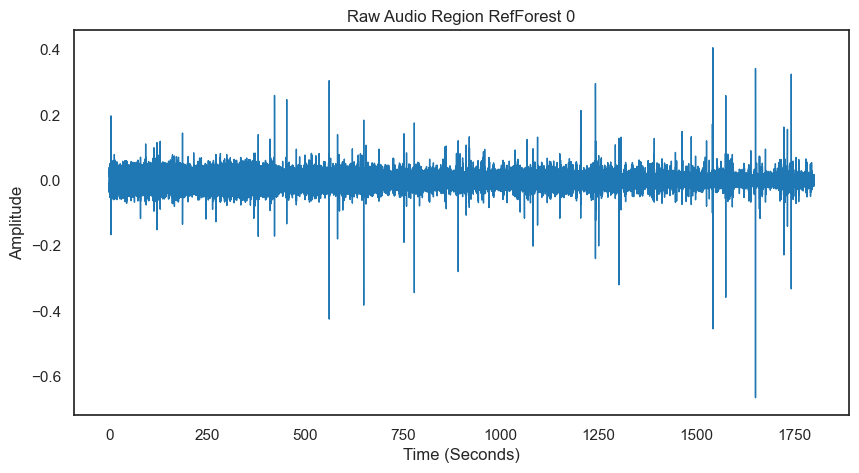

In [18]:
# TODO: save in cluster
# Calculate the time for each sample
time = np.arange(0, len(y)) / sr
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, y, lw=1, color=color_pal[0])
title = f'Raw Audio Region {region} {si}'
plt.title(title)
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.show()

In [19]:
# TODO: save in cluster
# Create the time vector to plot
# time = np.arange(0, len(y_rn)) / sr
time = np.arange(0, len(y_rn_ns_p)) / sr
# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(time, y_c, lw=1, color=color_pal[0], label='Original')
plt.plot(time, y_rn_ns_p, lw=1, color=color_pal[2], label='Non-Stationary Denoised')
plt.plot(time, y_rn_st_p, lw=1, color=color_pal[1], label='Stationary Denoised')
title = f'Comparison Reduced Noise Audio {region} {si}'
plt.title(title)
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.legend(loc='upper left')
plt.show()

MemoryError: Unable to allocate 1.29 GiB for an array with shape (2, 86400000) and data type float64

<Figure size 1000x500 with 1 Axes>

In [20]:
# PARALLEL split_freq_band => ~6sec
print('###', 'PARALLEL split_freq_band')
split_y_rn_st_split = Parallel(n_jobs=-1, verbose=1)(delayed(split_freq_band)(y_i) for y_i in split_y_rn_st)
split_y_rn_ns_split = Parallel(n_jobs=-1, verbose=1)(delayed(split_freq_band)(y_i) for y_i in split_y_rn_ns)

### PARALLEL split_freq_band


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 288 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:    7.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 352 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:    7.6s finished


In [21]:
print('####', 'PARALLEL SPLIT DENOISE Y_C SPLIT PER FREQUENCY',
      len(split_y_rn_st_split), len(split_y_rn_st_split[0]), len(split_y_rn_st_split[0][0]),
      split_y_rn_st_split[0][0][:9])

#### PARALLEL SPLIT DENOISE Y_C SPLIT PER FREQUENCY 600 10 3000 [ 2.82371076e-04  1.35098425e-05  4.15226663e-06  1.20837701e-06
 -1.47524931e-07 -8.85725222e-07 -1.32139615e-06 -1.58718218e-06
 -1.74801888e-06]


In [22]:
# REARRANGE THE SIGNAL
bandas = 10
y_rn_split_st_10 = []
y_rn_split_ns_10 = []
for b in range(0, bandas):
    b_split_st = []
    b_split_ns = []
    for e, split_y in enumerate(split_y_rn_st_split):
        b_split_st.extend(split_y[b])
    for e, split_y in enumerate(split_y_rn_st_split):
        b_split_ns.extend(split_y[b])
    # print(e, 'banda:', b)
    y_rn_split_st_10.append(b_split_st)
    y_rn_split_ns_10.append(b_split_ns)

In [23]:
print('###', 'REARRANGED THE SIGNAL PER 10 FREQUENCIES', type(y_rn_split_st_10), len(y_rn_split_st_10),
      len(y_rn_split_st_10[0]))

### REARRANGED THE SIGNAL PER 10 FREQUENCIES <class 'list'> 10 1800000


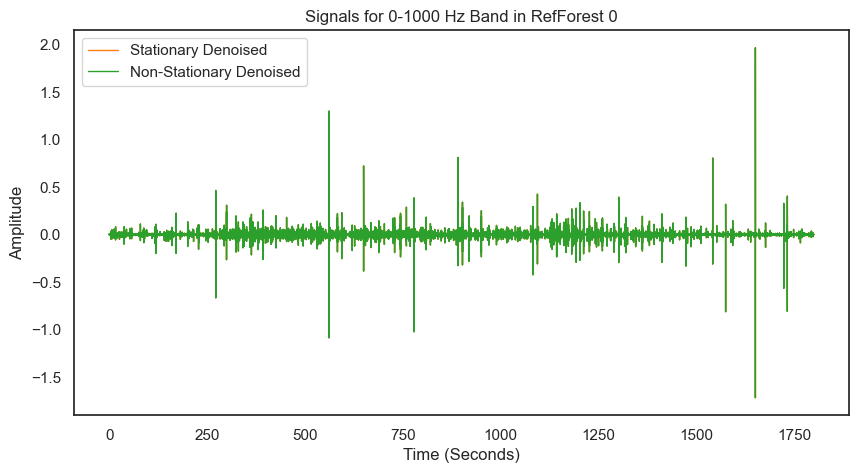

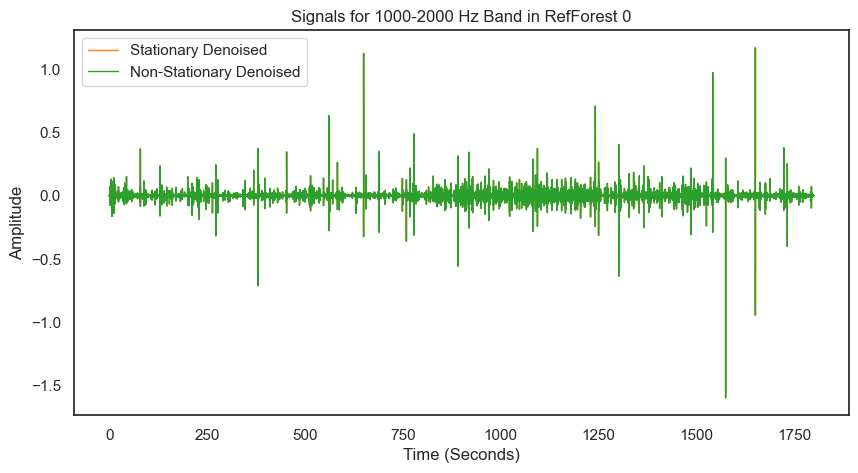

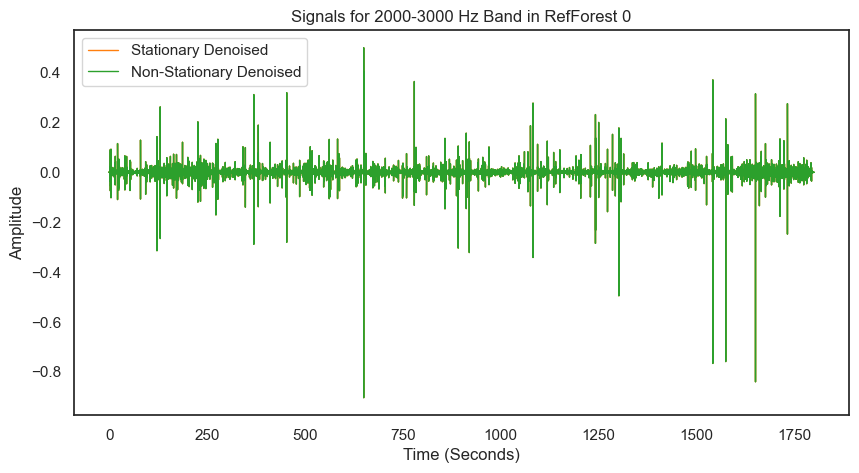

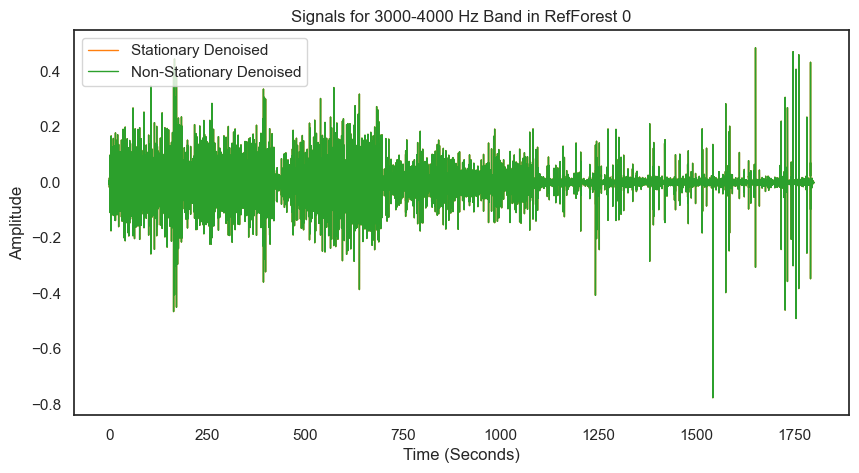

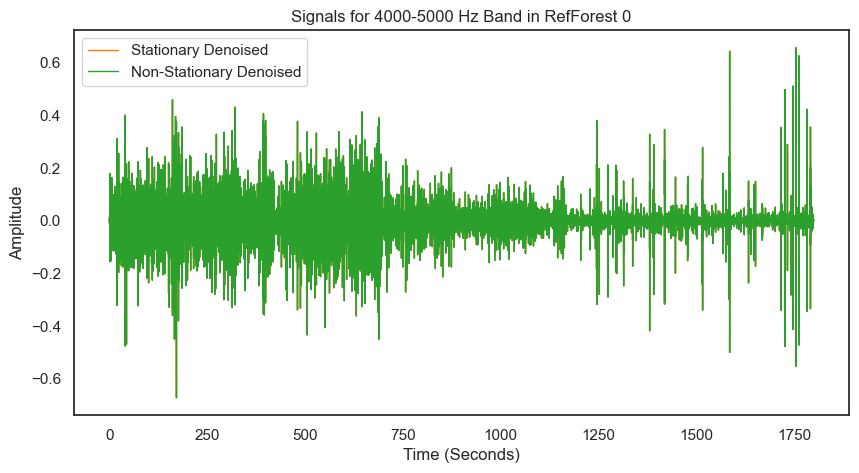

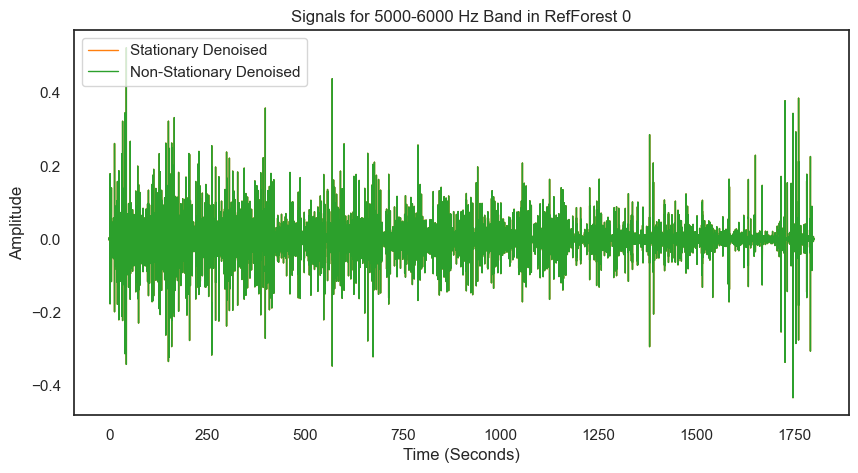

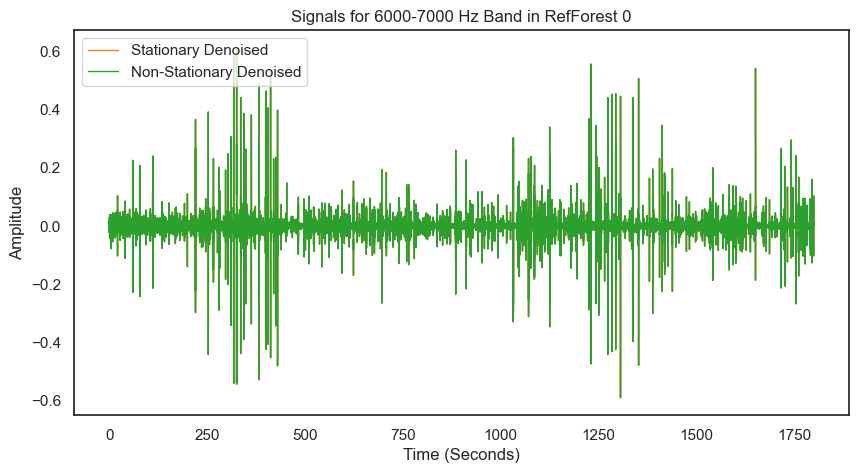

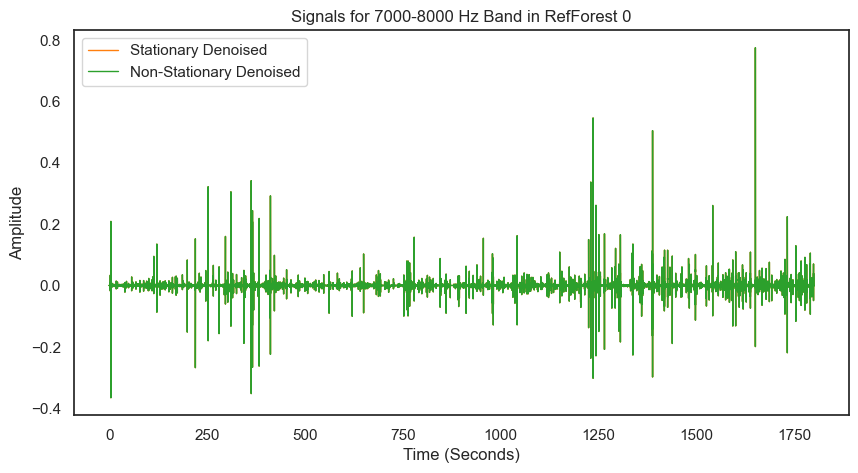

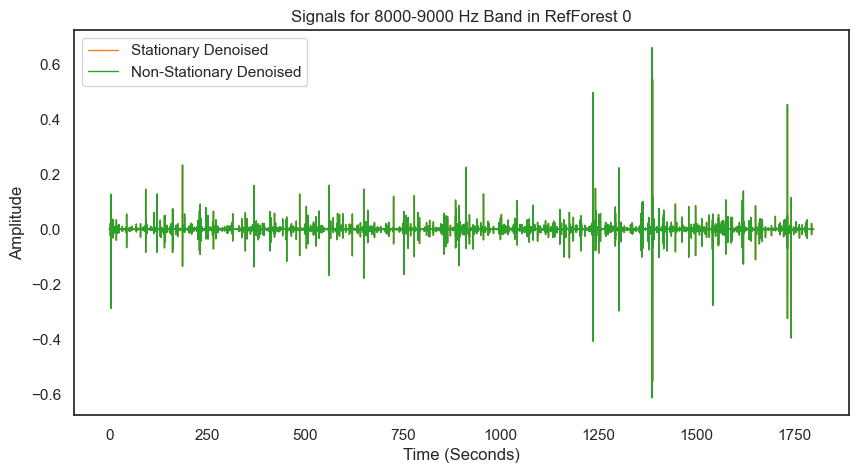

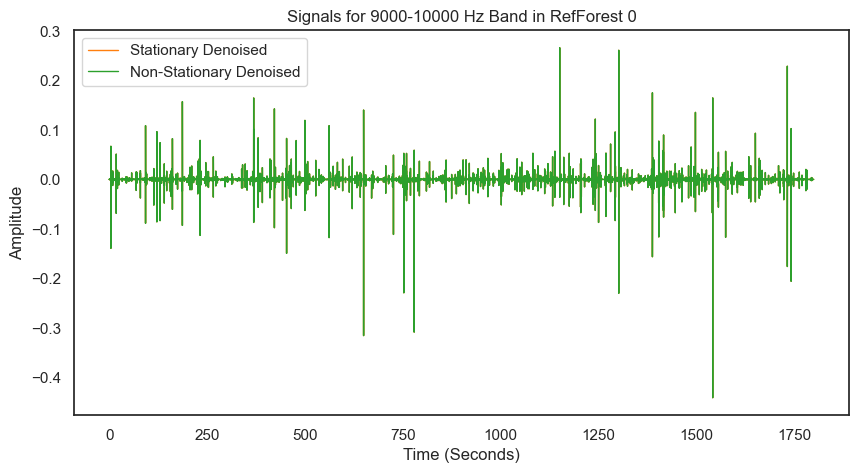

In [24]:
# TODO: save in cluster
def plot_split_signal(s_split_0: List[np.ndarray] = None, s_split_1: List[np.ndarray] = None, bandwidth: int = 1000, region=region, si=si):
    if not s_split_1:
        for i, y_band_0 in enumerate(s_split_0):
            # Calculate the time for each sample
            # time = np.arange(0, len(y_rn)) / sr
            time_band = np.arange(0, len(y_band_0)) / bandwidth
            # Plot the signal
            plt.figure(figsize=(10, 5))
            plt.plot(time_band, y_band_0, lw=1, color=color_pal[1], label='Stationary Denoised')
            plt.title(f'Signal for {i * bandwidth}-{(i + 1) * bandwidth} Hz Band in {region} {si}')
            plt.xlabel('Time (Seconds)')
            plt.ylabel('Amplitude')
            plt.legend(loc='upper left')
            plt.show()
    elif (s_split_1 and s_split_1):
        for i, (y_band_0, y_band_1) in enumerate(zip(s_split_0, s_split_1)):
            # Calculate the time for each sample
            # time = np.arange(0, len(y_rn)) / sr
            time_band = np.arange(0, max([len(y_band_0), len(y_band_1)])) / bandwidth
            # Plot the signal
            plt.figure(figsize=(10, 5))
            plt.plot(time_band, y_band_0, lw=1, color=color_pal[1], label='Stationary Denoised')
            plt.plot(time_band, y_band_1, lw=1, color=color_pal[2], label='Non-Stationary Denoised')
            plt.title(f'Signals for {i * bandwidth}-{(i + 1) * bandwidth} Hz Band in {region} {si}')
            plt.xlabel('Time (Seconds)')
            plt.ylabel('Amplitude')
            plt.legend(loc='upper left')
            plt.show()


# plot_split_signal(y_rn_split)
plot_split_signal(y_rn_split_st_10, y_rn_split_ns_10)

### Compute Sliding Window (60 secs)

In [25]:
print('###', 'COMPUTE SLIDING WINDOW WITH SUM')
# bandwidth, secs, w_size_mins = 1000, 60, 0.06  # every 3.6 secs

### COMPUTE SLIDING WINDOW WITH SUM


In [26]:
suma, bandwidth, secs, w_size_mins = True, 1000, 60, 0.06  # every 3.6 secs


def sum_this_sliding_window(data, size=bandwidth * secs, stepsize=int(bandwidth * secs * w_size_mins),
                            padded=False, axis=-1, copy=False, suma=True, average=False):
    if axis >= data.ndim:
        raise ValueError("Axis value out of range")
    if stepsize < 1:
        raise ValueError("Stepsize may not be zero or negative")
    if size > data.shape[axis]:
        raise ValueError("Sliding window size may not exceed size of selected axis")
    shape = list(data.shape)
    shape[axis] = np.floor(data.shape[axis] / stepsize - size / stepsize + 1).astype(int)
    shape.append(size)
    strides = list(data.strides)
    strides[axis] *= stepsize
    strides.append(data.strides[axis])
    strided = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)
    if suma:
        return [np.sum(s, axis=0) for s in strided.copy()] if copy else [np.sum(s, axis=0) for s in strided]
    elif average:
        return [np.mean(s, axis=0) for s in strided.copy()] if copy else [np.mean(s, axis=0) for s in strided]
    else:
        return strided.copy() if copy else strided

In [27]:
# TESTING
s = np.array(y_rn_split_st_10)
print(type(s), len(s))
w_test = sum_this_sliding_window(s, suma=False)  #, size=bandwidth * secs, stepsize=int(bandwidth * secs * w_size_mins))
sum_w_test = sum_this_sliding_window(s)  #, size=bandwidth * secs, stepsize=int(bandwidth * secs * w_size_mins))

<class 'numpy.ndarray'> 10


In [28]:
# TESTING
print(w_test[0][:3], len(w_test[0]), len(w_test))
print(sum_w_test[0][:3], len(sum_w_test), type(sum_w_test), type(sum_w_test[0]))

[[ 2.82371076e-04  1.35098425e-05  4.15226663e-06 ... -2.94875297e-04
  -2.87410416e-04 -2.54334321e-04]
 [ 4.48588356e-04 -4.99871250e-04  5.08463342e-04 ... -8.09153334e-06
  -8.13510795e-06 -8.17922632e-06]
 [-4.21849402e-04 -1.80529545e-04 -1.03434634e-03 ... -1.07610022e-06
  -1.02591476e-06 -9.74268457e-07]] 484 10
[-0.09755341  0.07047672  0.06592815] 10 <class 'list'> <class 'numpy.ndarray'>


In [29]:
# sum_y_rn_st_split optimized => 3sec
suma, bandwidth, secs, w_size_mins = True, 1000, 60, 0.06  # 0.06 => every 3.6 secs

sum_y_rn_st_split = [sum_this_sliding_window(s, size=bandwidth * secs, stepsize=int(bandwidth * secs * w_size_mins))
                     for s in tqdm(np.array(y_rn_split_st_10))]
sum_y_rn_ns_split = [sum_this_sliding_window(s, size=bandwidth * secs, stepsize=int(bandwidth * secs * w_size_mins))
                     for s in tqdm(np.array(y_rn_split_ns_10))]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [30]:
print('###', 'COMPUTE SLIDING WINDOW WITH SUM', type(sum_y_rn_st_split), sum_y_rn_st_split[0][:3],
      type(sum_y_rn_st_split[0]), len(sum_y_rn_st_split[0]))

### COMPUTE SLIDING WINDOW WITH SUM <class 'list'> [-0.0013886416656389428, 0.0004170674870494287, -0.0746214308639846] <class 'list'> 484


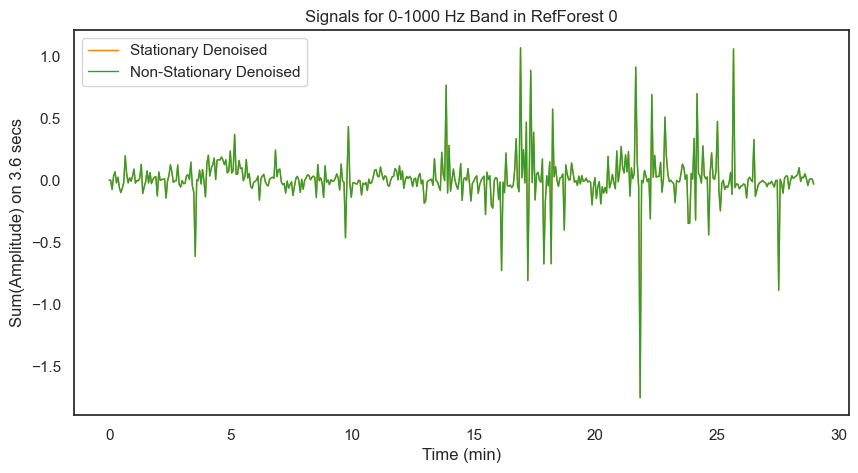

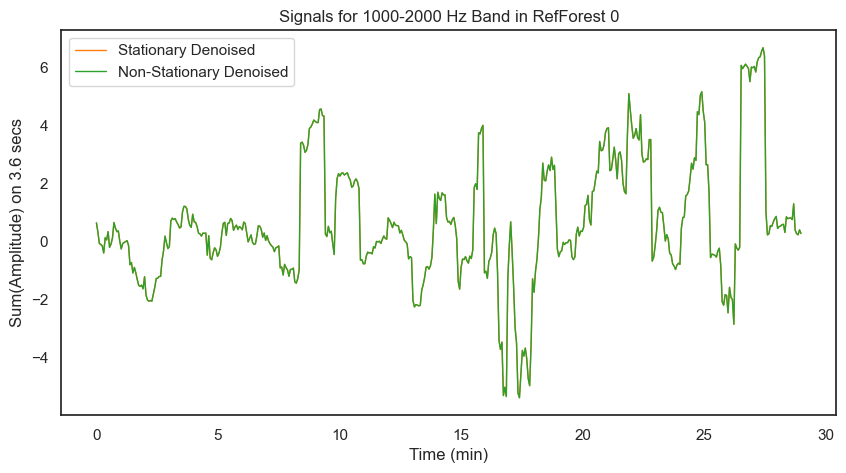

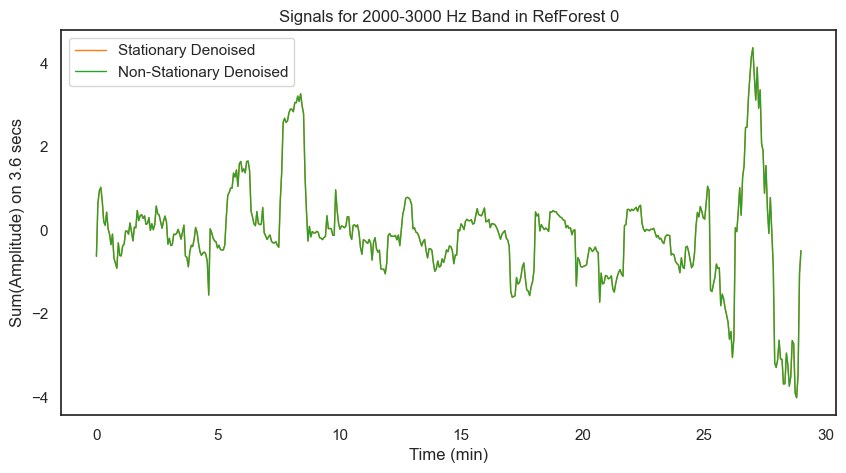

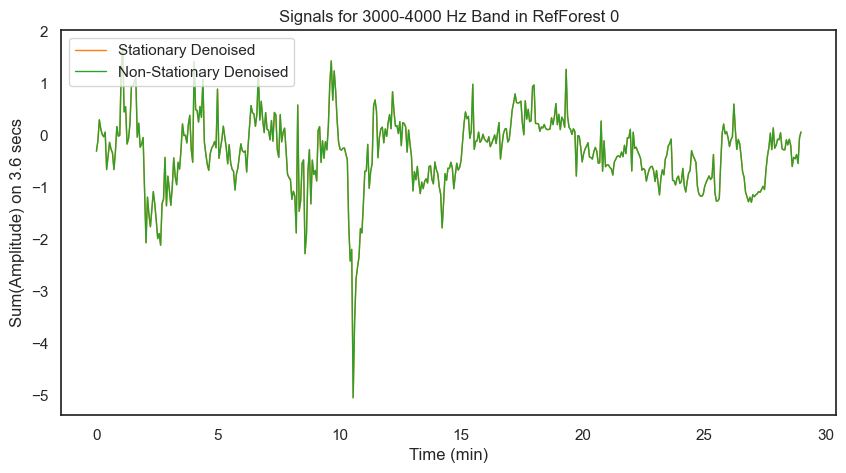

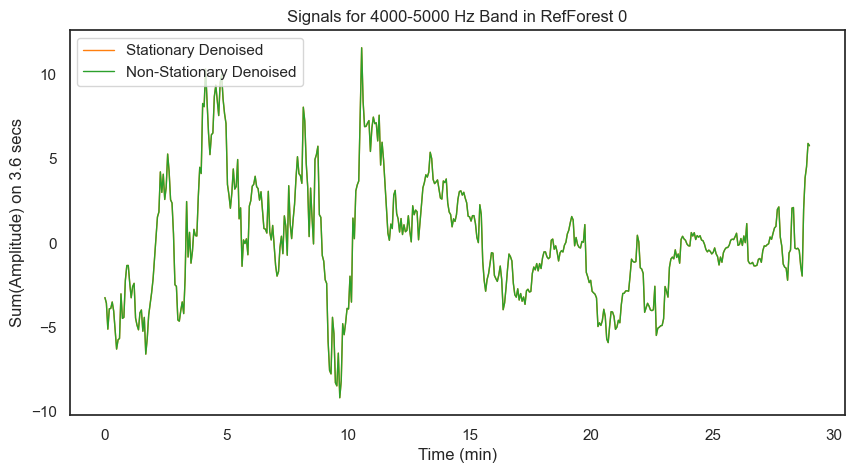

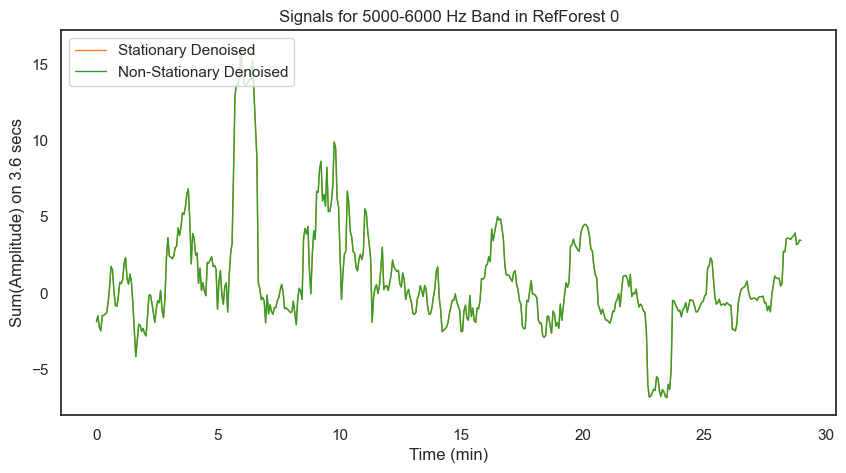

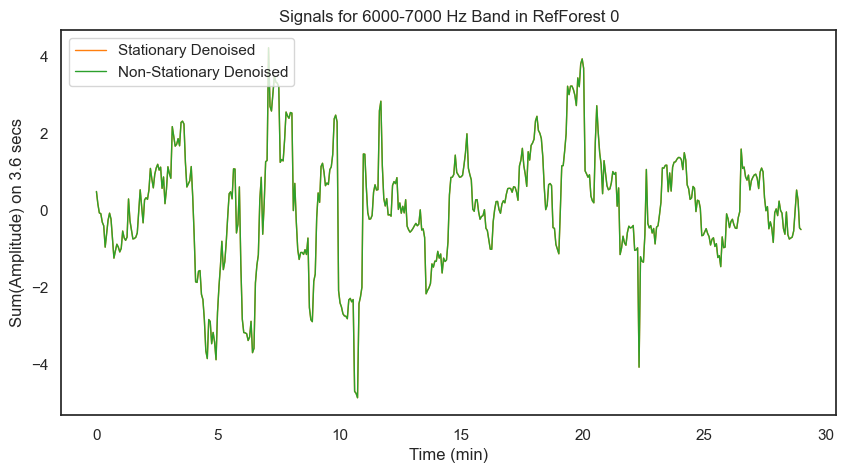

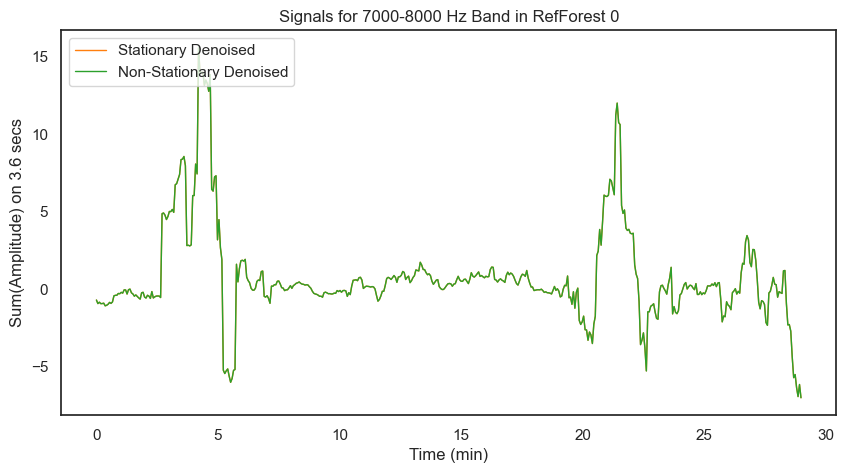

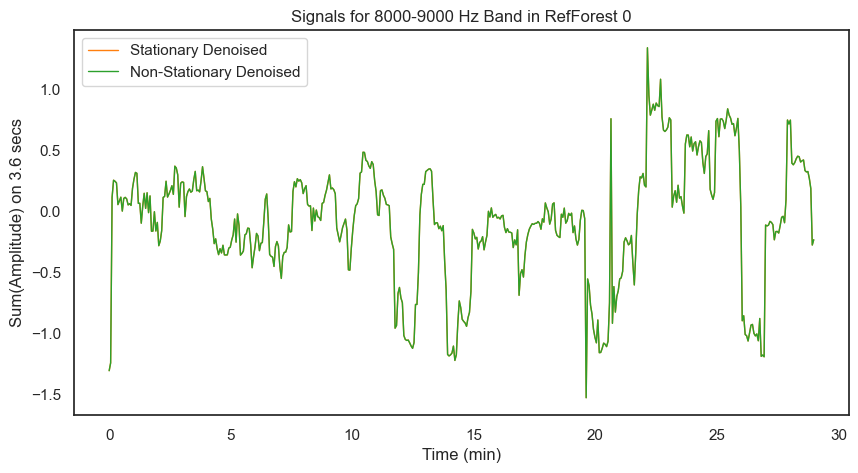

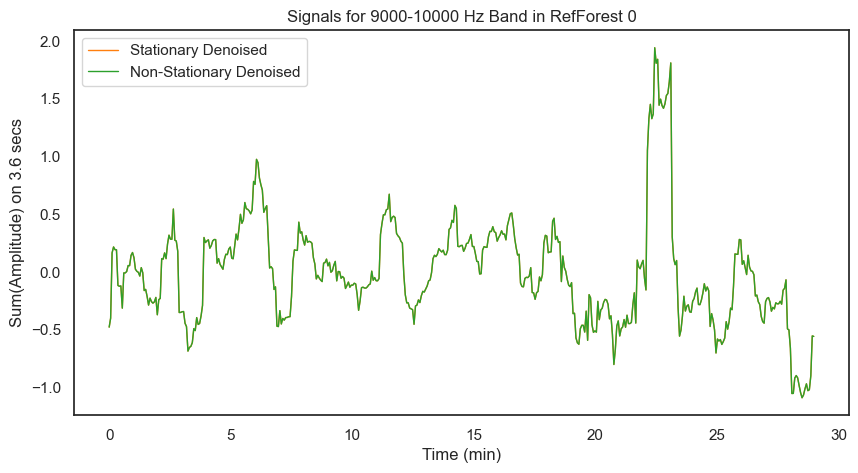

In [31]:
# TODO: save in cluster
def plot_mean_split_signal(s_split_0: List[np.ndarray] = None, s_split_1: List[np.ndarray] = None, y_label: str = '',
                           bandwidth: int = 1000, secs=secs,w_size_mins=w_size_mins, region=region, si=si):
    if not s_split_1:
        for i, y_band_0 in enumerate(s_split_0):
            # time = np.arange(0, len(y_rn)) / sr
            time_band = np.arange(0, len(y_band_0)) * w_size_mins  # / bandwidth
            plt.figure(figsize=(10, 5))
            plt.plot(time_band, y_band_0, lw=1, color=color_pal[1], label='Stationary Denoised')
            plt.title(f'Signal for {i * bandwidth}-{(i + 1) * bandwidth} Hz Band in {region} {si}')
            plt.xlabel('Time (min)')
            plt.ylabel(f'{y_label}(Amplitude) on {round(secs*w_size_mins,1)} secs')
            plt.legend(loc='upper left')
            plt.show()
    elif (s_split_1 and s_split_1):
        for i, (y_band_0, y_band_1) in enumerate(zip(s_split_0, s_split_1)):
            # time = np.arange(0, len(y_rn)) / sr
            time_band = np.arange(0, max([len(y_band_0), len(y_band_1)])) * w_size_mins  # / bandwidth
            plt.figure(figsize=(10, 5))
            plt.plot(time_band, y_band_0, lw=1, color=color_pal[1], label='Stationary Denoised')
            plt.plot(time_band, y_band_1, lw=1, color=color_pal[2], label='Non-Stationary Denoised')
            plt.title(f'Signals for {i * bandwidth}-{(i + 1) * bandwidth} Hz Band in {region} {si}')
            plt.xlabel('Time (min)')
            plt.ylabel(f'{y_label}(Amplitude) on {round(secs*w_size_mins,1)} secs')
            plt.legend(loc='upper left')
            plt.show()


plot_mean_split_signal(sum_y_rn_st_split, sum_y_rn_ns_split, y_label='Sum')

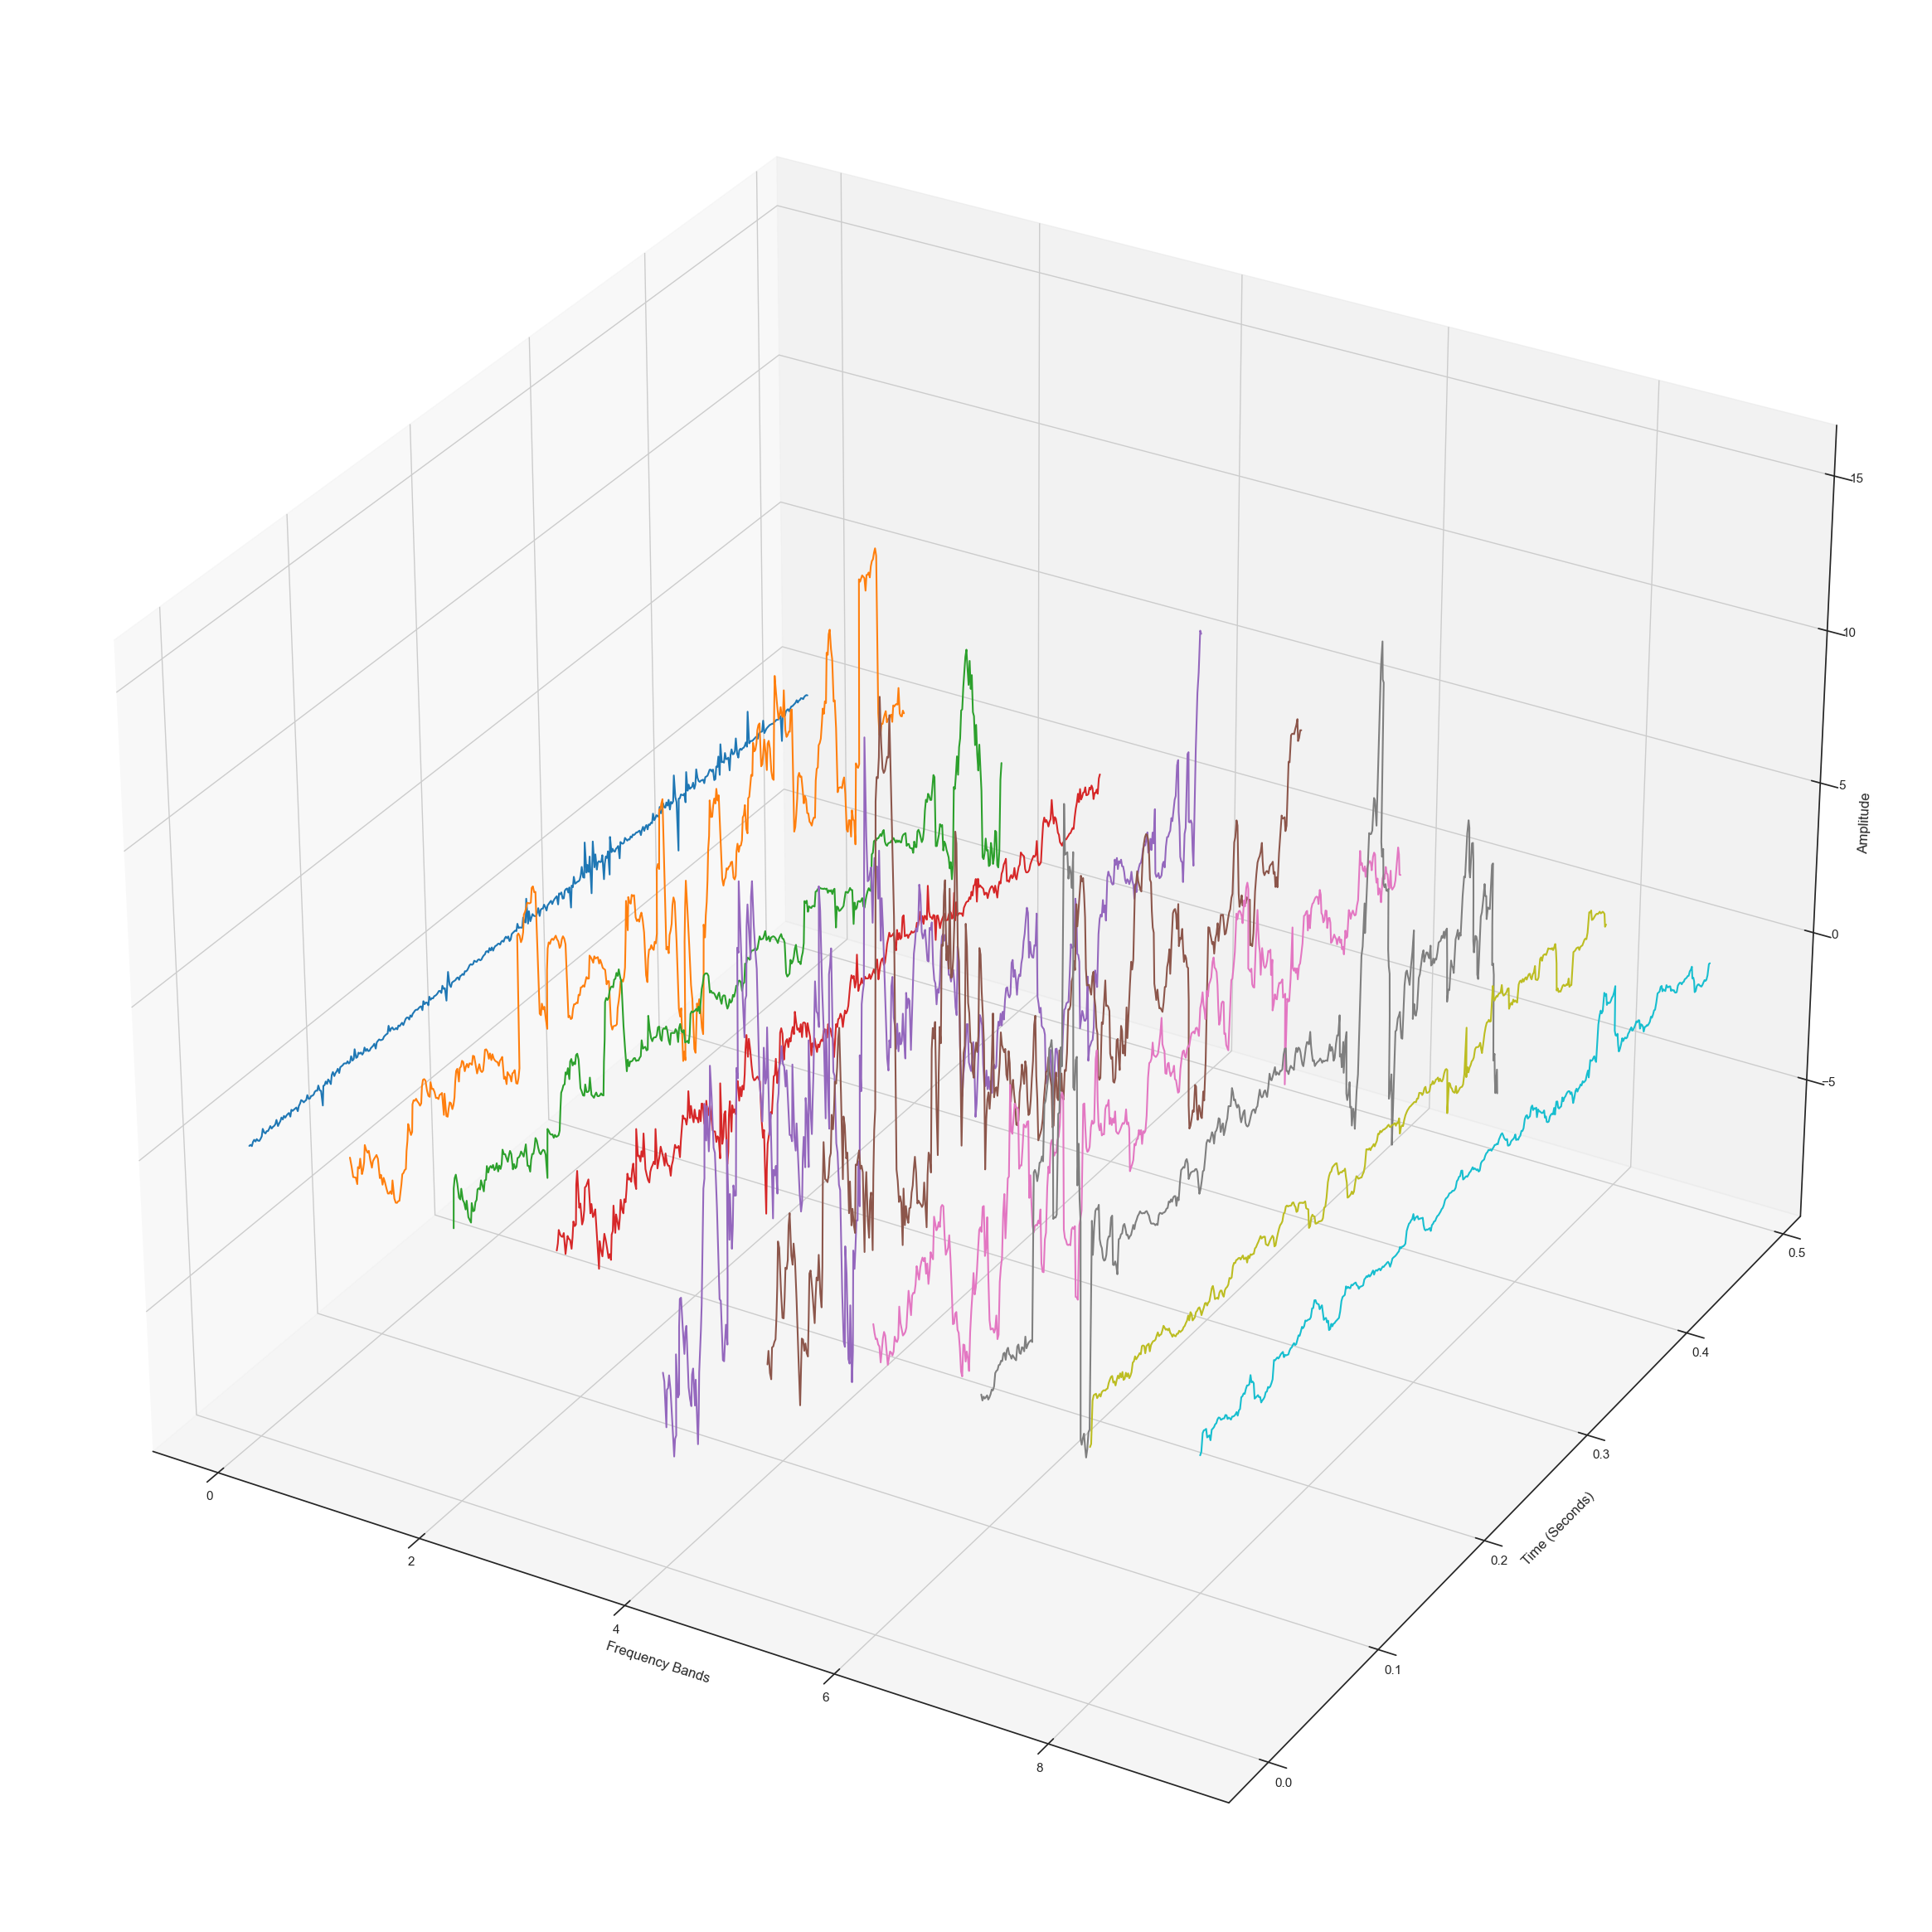

In [32]:
fig = plt.figure(figsize=(60, 30))
ax = fig.add_subplot(111, projection='3d')
for i, y in enumerate(np.array(sum_y_rn_ns_split)):
    x = np.full(y.shape, i)
    time_band = np.arange(0, len(y)) / bandwidth
    ax.plot(x, time_band, y)

ax.set_xlabel('Frequency Bands')
ax.set_ylabel('Time (Seconds)')
ax.set_zlabel('Amplitude')
plt.show()

# Analysis using music theory

In [33]:
print('Aller mit Erfolg parceros!')

Aller mit Erfolg parceros!
